# Homework Starter — Stage 08 EDA

Fill in the marked TODOs. This notebook generates synthetic data so you can focus on the EDA flow. Replace with your dataset when ready.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
!pip install scipy
# !pip install pandas
!pip install seaborn
# !pip install matplotlib
# !pip install --upgrade pandas   # if an older pandas is already installed

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import skew, kurtosis
sns.set(context='talk', style='whitegrid')
np.random.seed(8)
pd.set_option('display.max_columns', 100)

# === Synthetic data generator (adapt or replace with your own data) ===
n = 160
df = pd.DataFrame({
    'date': pd.date_range('2021-02-01', periods=n, freq='D'),
    'region': np.random.choice(['North','South','East','West'], size=n),
    'age': np.random.normal(40, 8, size=n).clip(22, 70).round(1),
    'income': np.random.lognormal(mean=10.6, sigma=0.3, size=n).round(2),
    'transactions': np.random.poisson(lam=3, size=n),
})
base = df['income'] * 0.0015 + df['transactions']*18 + np.random.normal(0, 40, size=n)
df['spend'] = np.maximum(0, base).round(2)

# inject a bit of missingness and outliers
df.loc[np.random.choice(df.index, 5, replace=False), 'income'] = np.nan
df.loc[np.random.choice(df.index, 3, replace=False), 'spend'] = np.nan
df.loc[np.random.choice(df.index, 2, replace=False), 'transactions'] = df['transactions'].max()+12
df.head()

,date,region,age,income,transactions,spend
0,2021-02-01,West,37.6,28086.81,4,73.35
1,2021-02-02,North,43.0,33034.75,1,52.37
2,2021-02-03,South,38.2,50045.39,2,131.85
3,2021-02-04,South,24.9,39467.28,4,147.58
4,2021-02-05,South,59.8,31201.65,1,86.76


## 1) First look

In [3]:
df.info(), df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          160 non-null    datetime64[ns]
 1   region        160 non-null    object        
 2   age           160 non-null    float64       
 3   income        155 non-null    float64       
 4   transactions  160 non-null    int32         
 5   spend         157 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int32(1), object(1)
memory usage: 7.0+ KB


(None,
 date            0
 region          0
 age             0
 income          5
 transactions    0
 spend           3
 dtype: int64)

## 2) Numeric profile

In [4]:
desc = df[['age','income','transactions','spend']].describe().T
desc['skew'] = [skew(df[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df[c].dropna()) for c in desc.index]
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
age,160.0,40.018750,8.458676,22.00,34.70,40.15,44.925,61.10,0.069538,-0.080125
income,155.0,41983.866323,13262.457038,17928.80,32471.53,39332.52,49697.690,87052.40,0.993336,0.918722
transactions,160.0,3.237500,2.585610,0.00,2.00,3.00,4.000,20.00,3.466078,19.984802
spend,157.0,117.291592,51.768645,0.54,77.25,119.32,153.340,280.05,0.130860,-0.084917


## 2b) Categorical profile

`.describe()` above covers the **numeric** columns only. Every non-numeric column needs
its own look: how many distinct values it has, how lopsided the split is, and whether one
category dominates so heavily that it will be useless as a feature.

`region` is the categorical column in this synthetic set. Your own dataset may have
several — profile all of them.


date - value counts:
date
2021-02-01    1
2021-02-02    1
2021-02-03    1
2021-02-04    1
2021-02-05    1
             ..
2021-07-06    1
2021-07-07    1
2021-07-08    1
2021-07-09    1
2021-07-10    1
Name: count, Length: 160, dtype: int64

date - proportions:
date
2021-02-01    0.00625
2021-02-02    0.00625
2021-02-03    0.00625
2021-02-04    0.00625
2021-02-05    0.00625
               ...   
2021-07-06    0.00625
2021-07-07    0.00625
2021-07-08    0.00625
2021-07-09    0.00625
2021-07-10    0.00625
Name: proportion, Length: 160, dtype: float64

region - value counts:
region
West     47
East     42
South    36
North    35
Name: count, dtype: int64

region - proportions:
region
West     0.29375
East     0.26250
South    0.22500
North    0.21875
Name: proportion, dtype: float64


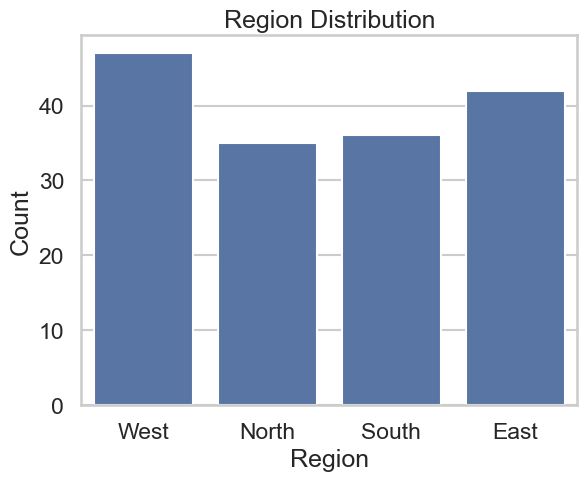

In [7]:
# TODO: value counts for every non-numeric column.
#   Hint: df.select_dtypes(exclude='number').columns gives you the list.
#   Print counts AND proportions — a raw count hides how lopsided a split is.
categorical_cols = df.select_dtypes(exclude='number').columns

for col in categorical_cols:
    print(f"\n{col} - value counts:")
    print(df[col].value_counts())
    
    print(f"\n{col} - proportions:")
    print(df[col].value_counts(normalize=True))


# TODO: plot one of them with sns.countplot (the lecture uses this in section 3).
# Plot the first categorical variable
sns.countplot(data=df, x='region')
plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

## 3) Distributions — two worked examples below; add at least one more

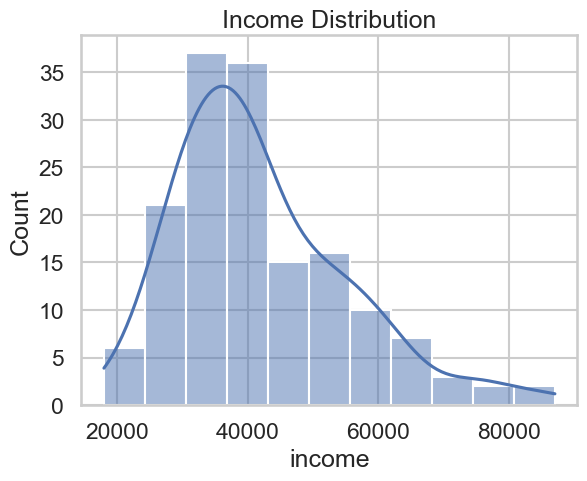

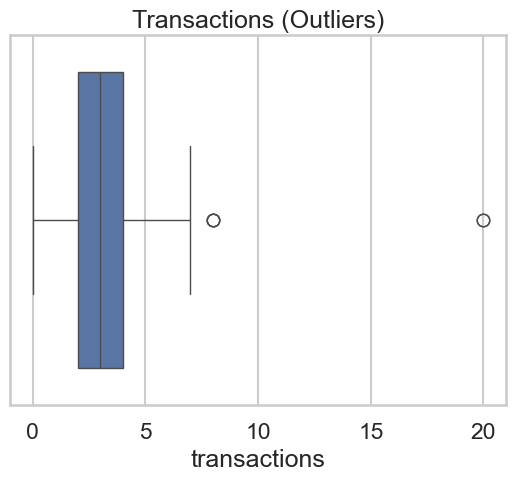

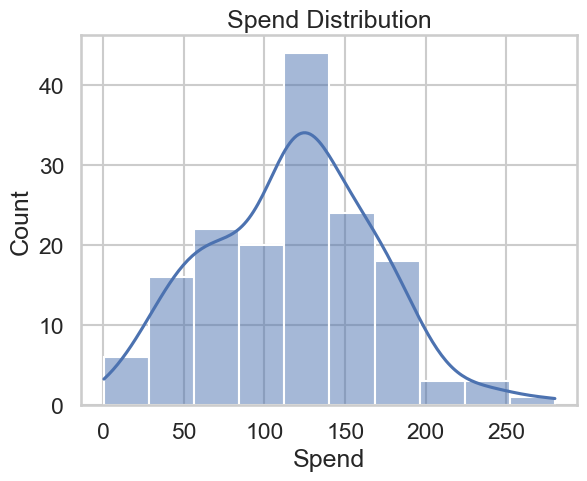

In [8]:
# Example 1 of 2 — histogram + KDE. Keep it, or swap in a column of your own.
sns.histplot(df['income'], kde=True)
plt.title('Income Distribution')
plt.show()

# Example 2 of 2 — boxplot, to expose outliers.
#
# TODO: add ONE more distribution below, on a column of your choosing (3 are required).
sns.boxplot(x=df['transactions'])
plt.title('Transactions (Outliers)')
plt.show()

# 3 — Spend distribution
sns.histplot(df['spend'], kde=True)
plt.title('Spend Distribution')
plt.xlabel('Spend')
plt.ylabel('Count')
plt.show()

## 4) Relationships — both are worked below; swap in your own columns

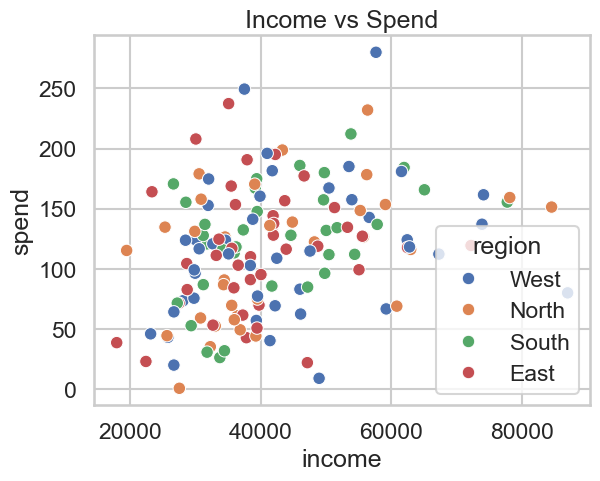

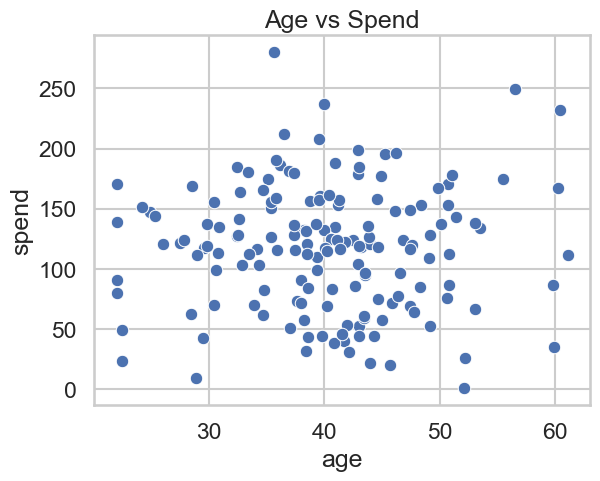

In [9]:
sns.scatterplot(data=df, x='income', y='spend', hue='region')
plt.title('Income vs Spend')
plt.show()

sns.scatterplot(data=df, x='age', y='spend')
plt.title('Age vs Spend')
plt.show()

## 4b) Over time

Nothing above uses the `date` column — and a dataset with a date almost always has
something to say along it: a trend, a seasonal cycle, or a level shift where behaviour
changed.

This is not optional detail. Stage 09 builds lag and rolling features on exactly this
axis, and stage 10b splits the data on it. What you find here decides what those stages
can do — and if the rows are out of order, or there are gaps in the dates, both of
those stages produce nonsense without telling you.

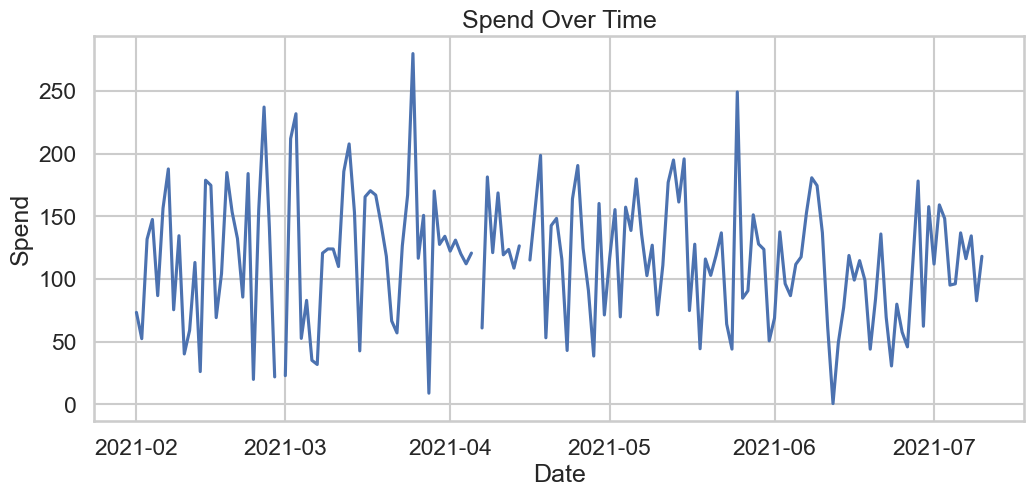

Date gaps:
date
1.0    159
Name: count, dtype: int64


In [10]:
# TODO: plot at least one variable over time.
#   Hint: sort by `date` first, then set it as the index. Order matters — a rolling
#   mean computed over out-of-order rows is meaningless.
df_time = df.sort_values('date').set_index('date')

# TODO: check for GAPS in the dates too. A rolling window that spans a missing week is
#   not the window you think it is.
plt.figure(figsize=(12, 5))
plt.plot(df_time.index, df_time['spend'])
plt.title('Spend Over Time')
plt.xlabel('Date')
plt.ylabel('Spend')
plt.show()

# TODO: then say what you see in a markdown cell: trend, seasonality, a level shift, or
#   genuinely nothing. 'Nothing' is a real finding if you can show it.
date_diff = df_time.index.to_series().diff().dt.days
print("Date gaps:")
print(date_diff.value_counts().sort_index())

### Time-Series Finding

The spend series does not show a clear long-term upward or downward trend.
There is also no obvious repeating seasonal pattern in this short synthetic dataset.
The main variation appears to be short-term fluctuation.

Because there is no strong visible seasonality, future feature engineering can focus
on rolling statistics and other variables rather than complex seasonal features.
The date column should still be kept in chronological order for future time-based analysis.

## 5) (Optional) Correlation matrix

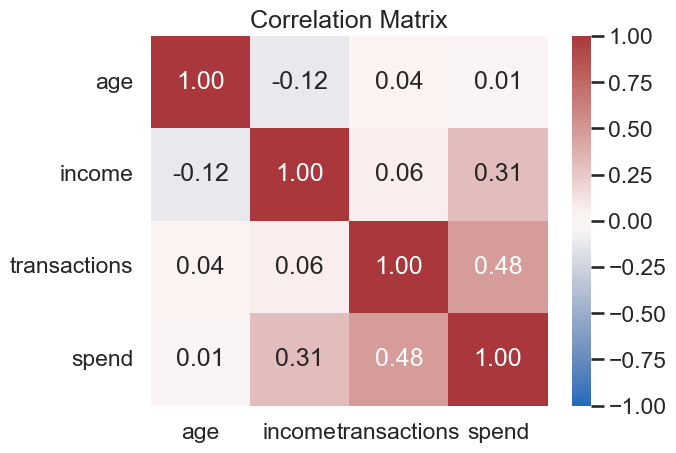

,age,income,transactions,spend
age,1.000000,-0.123160,0.037754,0.008174
income,-0.123160,1.000000,0.063573,0.307307
transactions,0.037754,0.063573,1.000000,0.480685
spend,0.008174,0.307307,0.480685,1.000000


In [11]:
corr = df[['age','income','transactions','spend']].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()
corr

## 5b) Your reusable helper — `src/eda.py`

The lecture built `eda_summary(df)` in its section 8. Copy it into `src/eda.py`, import
it here, and call it.

Stage 06 gave your project `src/cleaning.py` and stage 09 will want `src/features.py`.
This is stage 08's contribution to the same set, and the point is that your project keeps
ONE profiling function instead of ten pasted copies of it.

In [13]:
# TODO: create src/eda.py, paste the lecture's eda_summary() into it, then:
# TODO (stretch): have it flag columns that need attention before stage 09 — high
#   missingness, near-zero variance, or one category dominating.
from pathlib import Path
import sys

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eda import eda_summary

summary = eda_summary(df)

print("Dataset shape:")
print(summary["shape"])

print("\nMissing values:")
print(summary["missing_values"])

Dataset shape:
(160, 6)

Missing values:
date            0
region          0
age             0
income          5
transactions    0
spend           3
dtype: int64


## 6) Insights & Assumptions (write your commentary)
- TODO: Top 3 insights
- TODO: Assumptions & risks
- TODO: Next steps before modeling (cleaning & features)

## 6) Insights & Assumptions

### Top 3 Insights

1. Income has a right-skewed distribution, which suggests that a small number of observations have relatively high income values.

2. Transactions contains some unusually large values, which are visible in the boxplot and may influence summary statistics or future models.

3. Income and spend show a positive relationship, suggesting that income may be a useful predictor of spending.

### Assumptions & Risks

The dataset is synthetic, so the observed relationships may not represent real-world customer behavior.
Missing income and spend values should be handled carefully before modeling.
Potential outliers should not automatically be removed because they may represent real observations.

### Implications for Next Step

For Stage 09, I will create features that capture spending relative to income, recent spending behavior, and categorical information such as region.